In [1]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from env_v2 import motorEnv
from tqdm import tqdm

In [2]:
# malla=1 → Datos_v1.csv  |  malla=2 → Datos_v2.csv
env = motorEnv(malla=2)

# Arrays numpy pre-extraídos: acceso O(1) en el loop (evita pandas iloc)
VAR1 = env.VAR1
VAR2 = env.VAR2
W    = env.W

Entorno cargado: malla=2 | 179600 estados
Mínimo global: w=20.535195
Inicio: var1=0.0, var2=374.0, w=22.606224


In [3]:
EPISODIOS     = 100000
MAX_ITER      = 2500
ALPHA         = 0.5
GAMMA         = 0.999
EPSILON       = 1.0
EPSILON_MIN   = 0.01
EPSILON_DECAY = 0.99993

# Submuestreo para el gráfico de exploración (1 de cada N pasos)
# Reduce memoria x20 sin perder visibilidad de las trayectorias
SAMPLE_CADA   = 20

In [4]:
q_table = np.zeros((env.num_states, env.action_space.n))
print(f"Q-Table: {q_table.shape}")

historial_recompensas = []
historial_pasos       = []
mejor_recompensa      = -np.inf
mejor_pasos_al_min    = None
episodio_exito        = None

# Mejor camino completo (solo el episodio con mayor reward)
mejor_camino_v1 = []
mejor_camino_v2 = []
mejor_camino_w  = []
mejor_ep_num    = 0

# Trayectorias submuestreadas de todos los episodios (para gráfico exploración)
explorar_tray_v1 = []
explorar_tray_v2 = []

Q-Table: (179600, 4)


In [ ]:
print("=" * 65)
print(f"  Q-Learning — malla {1} | reward: -1 + 5·Δw | terminal: +10000")
print(f"  GAMMA={GAMMA} | ALPHA={ALPHA} | MAX_ITER={MAX_ITER} | Ep={EPISODIOS}")
print("=" * 65)

for episodio in tqdm(range(EPISODIOS), desc="Entrenando", ncols=80):
    estado = env.reset()

    recompensa_acumulada = 0.0
    pasos_dados          = 0
    llego_al_minimo      = False

    ep_v1 = [VAR1[estado]]
    ep_v2 = [VAR2[estado]]
    ep_w  = [W[estado]]

    tray_v1 = [VAR1[estado]]
    tray_v2 = [VAR2[estado]]

    for paso in range(MAX_ITER):
        pasos_dados += 1

        if np.random.uniform(0, 1) < EPSILON:
            accion = env.action_space.sample()
        else:
            accion = np.argmax(q_table[estado])

        siguiente_estado, recompensa, done, _ = env.step(accion)

        if paso == MAX_ITER - 1 and not done:
            recompensa -= 20.0
            done = True

        mejor_proxima = np.argmax(q_table[siguiente_estado])
        q_table[estado, accion] += ALPHA * (
            recompensa
            + GAMMA * q_table[siguiente_estado, mejor_proxima]
            - q_table[estado, accion]
        )

        estado = siguiente_estado
        ep_v1.append(VAR1[estado])
        ep_v2.append(VAR2[estado])
        ep_w.append(W[estado])

        if paso % SAMPLE_CADA == 0:
            tray_v1.append(VAR1[estado])
            tray_v2.append(VAR2[estado])

        recompensa_acumulada += recompensa

        if done:
            if W[estado] == env.w_min:
                llego_al_minimo = True
                if mejor_pasos_al_min is None or pasos_dados < mejor_pasos_al_min:
                    mejor_pasos_al_min = pasos_dados
                    episodio_exito     = episodio + 1
            break

    explorar_tray_v1.append(tray_v1)
    explorar_tray_v2.append(tray_v2)

    if recompensa_acumulada > mejor_recompensa:
        mejor_recompensa = recompensa_acumulada
        mejor_camino_v1  = ep_v1[:]
        mejor_camino_v2  = ep_v2[:]
        mejor_camino_w   = ep_w[:]
        mejor_ep_num     = episodio + 1

    EPSILON = max(EPSILON_MIN, EPSILON * EPSILON_DECAY)
    historial_recompensas.append(recompensa_acumulada)
    historial_pasos.append(pasos_dados)

    if (episodio + 1) % 1000 == 0:
        media = np.mean(historial_recompensas[-100:])
        exito = "MÍNIMO" if llego_al_minimo else "        "
        tqdm.write(f"Ep {episodio+1:4d}/{EPISODIOS}  {exito}  "
                   f"Pasos: {pasos_dados:4d}  "
                   f"Reward: {recompensa_acumulada:8.1f}  "
                   f"Media100: {media:8.1f}  "
                   f"ε={EPSILON:.3f}")

print("\n" + "=" * 65)
print("¡Entrenamiento terminado!")
print(f"Mejor reward acumulado: {mejor_recompensa:.1f}  (episodio {mejor_ep_num})")
if mejor_pasos_al_min is not None:
    print(f"Mínimo en episodio {episodio_exito} con {mejor_pasos_al_min} pasos")
    print(f"  Pasos mejor camino guardado: {len(env.shortest_path)}")
else:
    print("No alcanzó el mínimo — aumenta EPISODIOS")
print("=" * 65)

  Q-Learning — malla 1 | reward: -1 + 5·Δw | terminal: +10000
  GAMMA=0.999 | ALPHA=0.5 | MAX_ITER=2500 | Ep=100000


Entrenando:   1%|▎                        | 1003/100000 [00:41<58:51, 28.03it/s]

Ep 1000/100000            Pasos: 2500  Reward: -29443.1  Media100: -33290.5  ε=0.932


Entrenando:   2%|▍                      | 2004/100000 [01:21<1:05:14, 25.03it/s]

Ep 2000/100000            Pasos: 2500  Reward: -32014.8  Media100: -30485.9  ε=0.869


...

Ep 98000/100000  ✓ MÍNIMO  Pasos:  647  Reward:   9263.7  Media100:   9318.6  ε=0.010


Entrenando:  99%|██████████████████████▊| 99026/100000 [51:03<00:07, 137.38it/s]

Ep 99000/100000  ✓ MÍNIMO  Pasos:  646  Reward:   9363.7  Media100:   9295.7  ε=0.010


Entrenando: 100%|███████████████████████| 100000/100000 [51:09<00:00, 32.58it/s]

Ep 100000/100000  ✓ MÍNIMO  Pasos:  648  Reward:   9361.7  Media100:   9305.1  ε=0.010

¡Entrenamiento terminado!
Mejor reward acumulado: 9373.7  (episodio 95463)
★ Mínimo en episodio 95463 con 636 pasos
  Pasos mejor camino guardado: 636


In [ ]:
np.save("../../Modelos/q_tableV2.npy", q_table)
print("Q-Table guardada en q_tableV2.npy")

Q-Table guardada en q_table.npy


In [7]:
# Variables compartidas por todos los gráficos
w_final    = mejor_camino_w[-1]
pasos_best = len(mejor_camino_v1) - 1
min_mask   = W == env.w_min

C:\Users\Martin\AppData\Local\Temp\ipykernel_9968\607072869.py:23: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Martin\AppData\Local\Temp\ipykernel_9968\607072869.py:24: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('exploracion_v2.png', dpi=120, bbox_inches='tight', facecolor='black')
c:\Users\Martin\.conda\envs\env_R11_VC\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


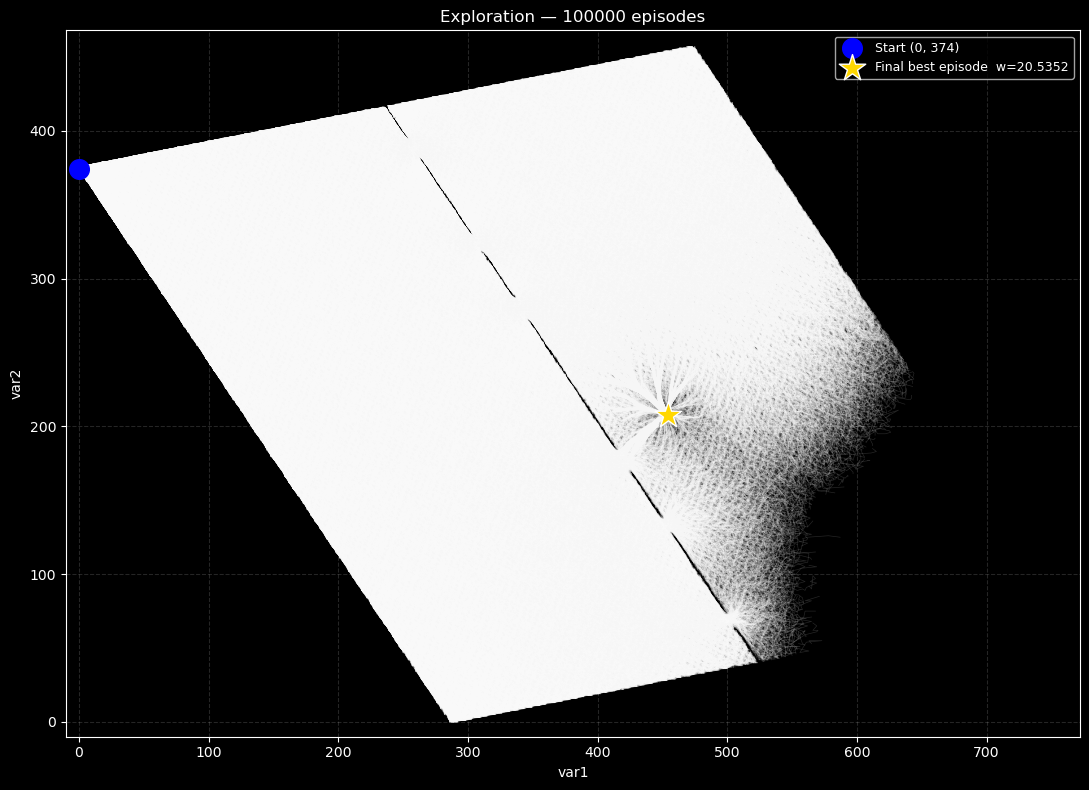

In [ ]:
# ── GRÁFICO 1: Exploración (fondo negro) ─────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(11, 8))
fig1.patch.set_facecolor('black')
ax1.set_facecolor('black')

for v1s, v2s in zip(explorar_tray_v1, explorar_tray_v2):
    ax1.plot(v1s, v2s, color='white', linewidth=0.5, alpha=0.15)

ax1.scatter(VAR1[0], VAR2[0],
            color='blue', s=200, zorder=6, label=f'Start ({VAR1[0]:.0f}, {VAR2[0]:.0f})')
ax1.scatter(mejor_camino_v1[-1], mejor_camino_v2[-1],
            color='gold', marker='*', s=400, edgecolors='white', zorder=6,
            label=f'Final best episode  w={w_final:.4f}')

ax1.set_xlim(VAR1.min()-10, VAR1.max()+10)
ax1.set_ylim(VAR2.min()-10, VAR2.max()+10)
ax1.set_xlabel('var1', color='white'); ax1.set_ylabel('var2', color='white')
ax1.tick_params(colors='white')
for spine in ax1.spines.values(): spine.set_edgecolor('white')
ax1.legend(fontsize=9, facecolor='black', labelcolor='white')
ax1.set_title(f'Exploration — {EPISODIOS} episodes', color='white')
ax1.grid(True, linestyle='--', alpha=0.15, color='white')
plt.tight_layout()
plt.savefig('../../Graficos/exploracion_v2.png', dpi=120, bbox_inches='tight', facecolor='black')
plt.show()

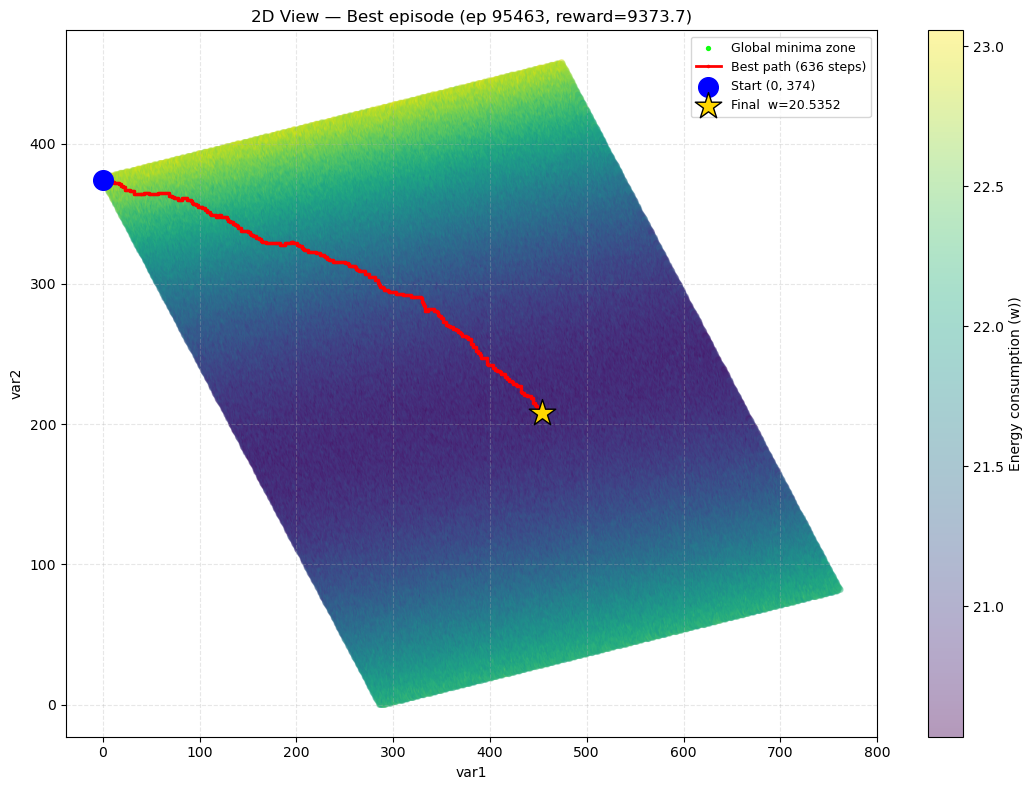

In [ ]:
# ── GRÁFICO 2: Malla 2D del mejor episodio ───────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(11, 8))
sc = ax2.scatter(VAR1, VAR2, c=W, cmap='viridis', alpha=0.4, s=15, zorder=1)
plt.colorbar(sc, label='Energy consumption (w))', ax=ax2)
ax2.scatter(VAR1[min_mask], VAR2[min_mask],
            color='lime', s=8, alpha=0.9, zorder=3, label='Global minima zone')
ax2.plot(mejor_camino_v1, mejor_camino_v2, color='red', linewidth=2,
         marker='.', markersize=3, zorder=4,
         label=f'Best path ({pasos_best} steps)')
ax2.scatter(mejor_camino_v1[0], mejor_camino_v2[0],
            color='blue', s=200, zorder=5, label=f'Start ({VAR1[0]:.0f}, {VAR2[0]:.0f})')
ax2.scatter(mejor_camino_v1[-1], mejor_camino_v2[-1],
            color='gold', marker='*', s=400, edgecolors='black', zorder=5,
            label=f'Final  w={w_final:.4f}')
ax2.set_xlabel('var1'); ax2.set_ylabel('var2')
ax2.set_title(f'2D View — Best episode (ep {mejor_ep_num}, reward={mejor_recompensa:.1f})')
ax2.legend(fontsize=9); ax2.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../../Graficos/mejor_ruta_v2_2d.png', dpi=120, bbox_inches='tight')
plt.show()

C:\Users\Martin\AppData\Local\Temp\ipykernel_9968\1238725392.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('mejor_ruta_v2_3d.png', dpi=120, bbox_inches='tight')


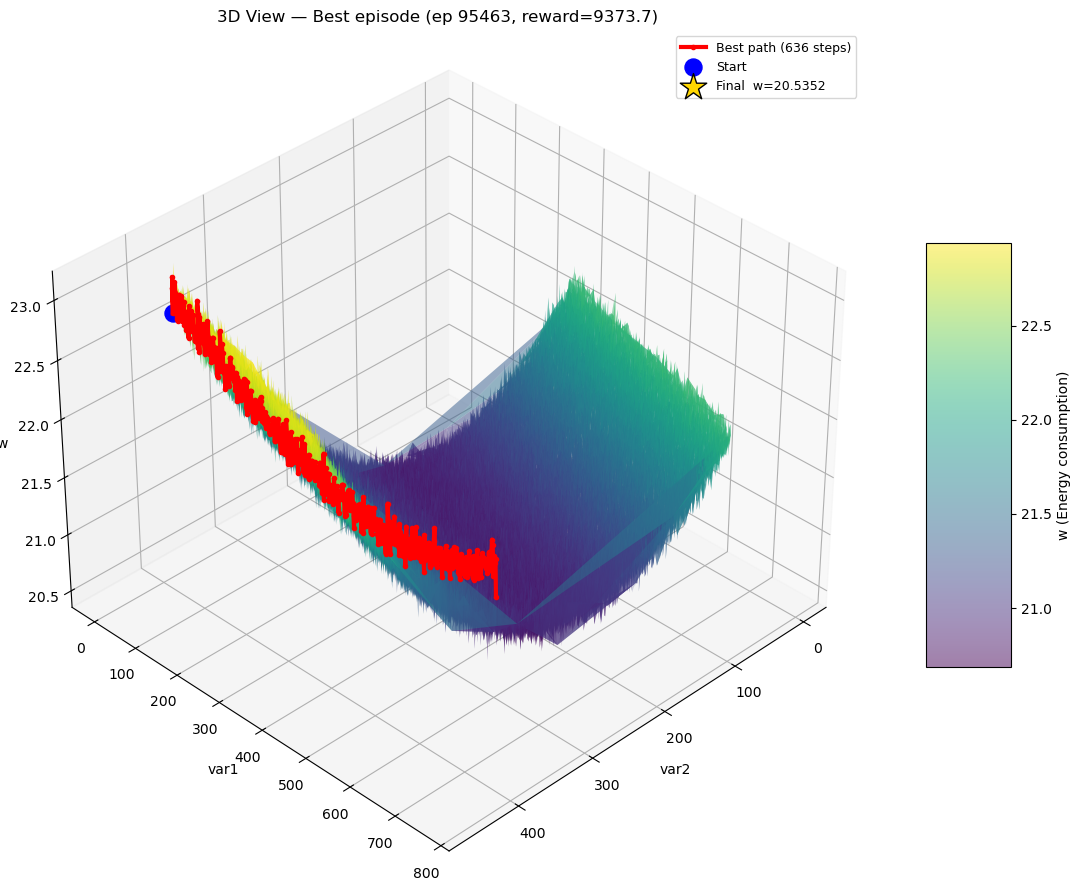

In [ ]:
# ── GRÁFICO 3: Malla 3D del mejor episodio
fig3 = plt.figure(figsize=(13, 9))
ax3  = fig3.add_subplot(111, projection='3d')
malla3d = ax3.plot_trisurf(VAR2, VAR1, W, cmap='viridis', alpha=0.5, edgecolor='none')
fig3.colorbar(malla3d, ax=ax3, shrink=0.5, aspect=5, label='w (Energy consumption)')
ax3.plot(mejor_camino_v2, mejor_camino_v1, mejor_camino_w,
         color='red', linewidth=3, marker='o', markersize=3,
         label=f'Best path ({pasos_best} steps)', zorder=5)
ax3.scatter(mejor_camino_v2[0],  mejor_camino_v1[0],  mejor_camino_w[0],
            color='blue', s=150, zorder=6, label='Start')
ax3.scatter(mejor_camino_v2[-1], mejor_camino_v1[-1], mejor_camino_w[-1],
            color='gold', marker='*', s=400, edgecolors='black',
            zorder=6, label=f'Final  w={w_final:.4f}')
ax3.set_xlabel('var2'); ax3.set_ylabel('var1'); ax3.set_zlabel('w')
ax3.set_title(f'3D View — Best episode (ep {mejor_ep_num}, reward={mejor_recompensa:.1f})')
ax3.legend(fontsize=9); ax3.view_init(elev=35, azim=45)
plt.tight_layout()
plt.savefig('../../Graficos/mejor_ruta_v2_3d.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
print(f"Pasos del último camino   : {len(env.last_path)}")
print(f"Pasos del mejor camino    : {len(env.shortest_path)}")
print(f"Mejor reward del training : {mejor_recompensa:.1f}  (ep {mejor_ep_num})")

Pasos del último camino   : 648
Pasos del mejor camino    : 636
Mejor reward del training : 9373.7  (ep 95463)


In [ ]:
# ── Cargar Q-Table guardada y evaluar ────────────────────────────────────────
q_table = np.load("../../Modelos/q_tableV2.npy")

EPISODIOS_EVAL = 5
total_pasos    = 0

for ep in range(EPISODIOS_EVAL):
    estado = env.reset()
    pasos  = 0
    done   = False

    while not done and pasos < MAX_ITER:
        accion = np.argmax(q_table[estado])
        estado, _, done, _ = env.step(accion)
        pasos += 1

    total_pasos += pasos
    print(f"  Eval ep {ep+1}: {pasos} pasos | "
          f"w final = {W[estado]:.6f} | "
          f"{'★ MÍNIMO' if W[estado]==env.w_min else 'no llegó'}")

print(f"\nMedia pasos: {total_pasos/EPISODIOS_EVAL:.1f}")

  Eval ep 1: 636 pasos | w final = 20.535195 | ★ MÍNIMO
  Eval ep 2: 636 pasos | w final = 20.535195 | ★ MÍNIMO
  Eval ep 3: 636 pasos | w final = 20.535195 | ★ MÍNIMO
  Eval ep 4: 636 pasos | w final = 20.535195 | ★ MÍNIMO
  Eval ep 5: 636 pasos | w final = 20.535195 | ★ MÍNIMO

Media pasos: 636.0


In [ ]:
import numpy as np
from env_v2 import motorEnv

env = motorEnv(malla=2)

# Cargar Q-Table guardada y evaluar
q_table = np.load("../../Modelos/q_tableV2.npy")
# O usar env.num_states directamente si instanciaste el entorno como 'env'
num_estados = q_table.shape[0] 

EPISODIOS_EVAL = 5
total_pasos    = 0
MAX_ITER       = 2000 # Asegúrate de tener este límite definido

for ep in range(EPISODIOS_EVAL):
    # Elegimos un punto de inicio aleatorio
    inicio_random = np.random.randint(0, num_estados)
    
    # Reseteamos pasándole ese inicio
    estado = env.reset(estado_inicial=inicio_random)
    
    pasos  = 0
    done   = False

    # Imprimimos desde dónde sale para poder rastrearlo
    w_inicial = env.W[estado]
    print(f"--- Ep {ep+1}: Saliendo de estado {estado} (w={w_inicial:.4f}) ---")

    while not done and pasos < MAX_ITER:
        accion = np.argmax(q_table[estado])
        estado, _, done, _ = env.step(accion)
        pasos += 1

    total_pasos += pasos
    
    # Imprimimos el resultado de este episodio
    w_final = env.W[estado]
    estado_llegada = "★ MÍNIMO" if w_final == env.w_min else "no llegó"
    print(f"  Resultado: {pasos} pasos | w final = {w_final:.6f} | {estado_llegada}\n")

print(f"Media pasos: {total_pasos/EPISODIOS_EVAL:.1f}")

Entorno cargado: malla=2 | 179600 estados
Mínimo global: w=20.535195
Inicio: var1=0.0, var2=374.0, w=22.606224
--- Ep 1: Saliendo de estado 115646 (w=21.1234) ---
  Resultado: 90 pasos | w final = 20.535195 | ★ MÍNIMO

--- Ep 2: Saliendo de estado 14938 (w=22.4523) ---
  Resultado: 2000 pasos | w final = 22.582093 | no llegó

--- Ep 3: Saliendo de estado 135460 (w=20.9548) ---
  Resultado: 2000 pasos | w final = 21.028400 | no llegó

--- Ep 4: Saliendo de estado 50623 (w=22.0853) ---
  Resultado: 2000 pasos | w final = 22.020216 | no llegó

--- Ep 5: Saliendo de estado 170320 (w=22.1102) ---
  Resultado: 2000 pasos | w final = 21.994773 | no llegó

Media pasos: 1618.0


In [ ]:
import pandas as pd

# Crear un DataFrame (tabla) combinando las listas del mejor episodio
df_mejor_recorrido = pd.DataFrame({
    'indice': range(len(mejor_camino_v1)),
    'var1': mejor_camino_v1,
    'var2': mejor_camino_v2,
    'w': mejor_camino_w
})

# Exportar la tabla a un archivo CSV sin incluir el índice automático de pandas
nombre_archivo = '../../Datos/Transformados/mejor_recorrido_agente.csv'
df_mejor_recorrido.to_csv(nombre_archivo, index=False)

# Mostrar un mensaje de confirmación y las primeras filas
print(f"Archivo '{nombre_archivo}' generado")
display(df_mejor_recorrido.head())

Archivo 'mejor_recorrido_agente.csv' generado


,indice,var1,var2,w
0,0,0.0,374.0,22.606224
1,1,1.0,374.0,22.819143
2,2,2.0,374.0,22.705076
3,3,3.0,374.0,22.769776
4,4,4.0,374.0,22.645869
